<a href="https://colab.research.google.com/github/noRenoSSD/PengolahanCitra_2025_Athaya/blob/main/Pertemuan3_PengolahanCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Praktikum 1. Transormasi Kurva (Citra Negatif)**

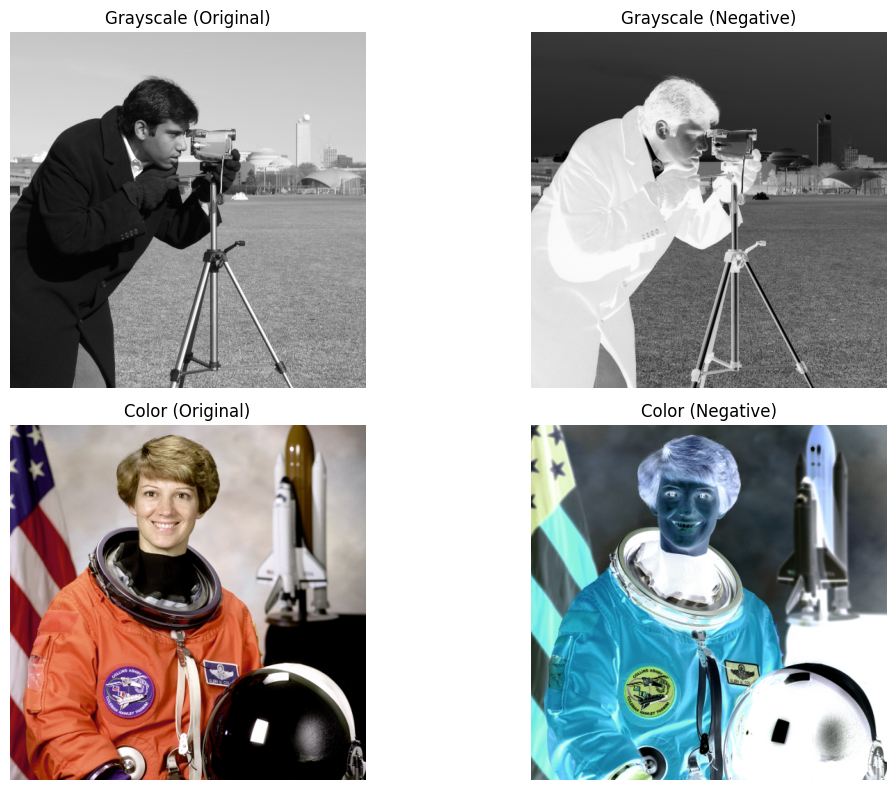

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Praktikum 2. Histogram dan Ekualisasi Histogram**

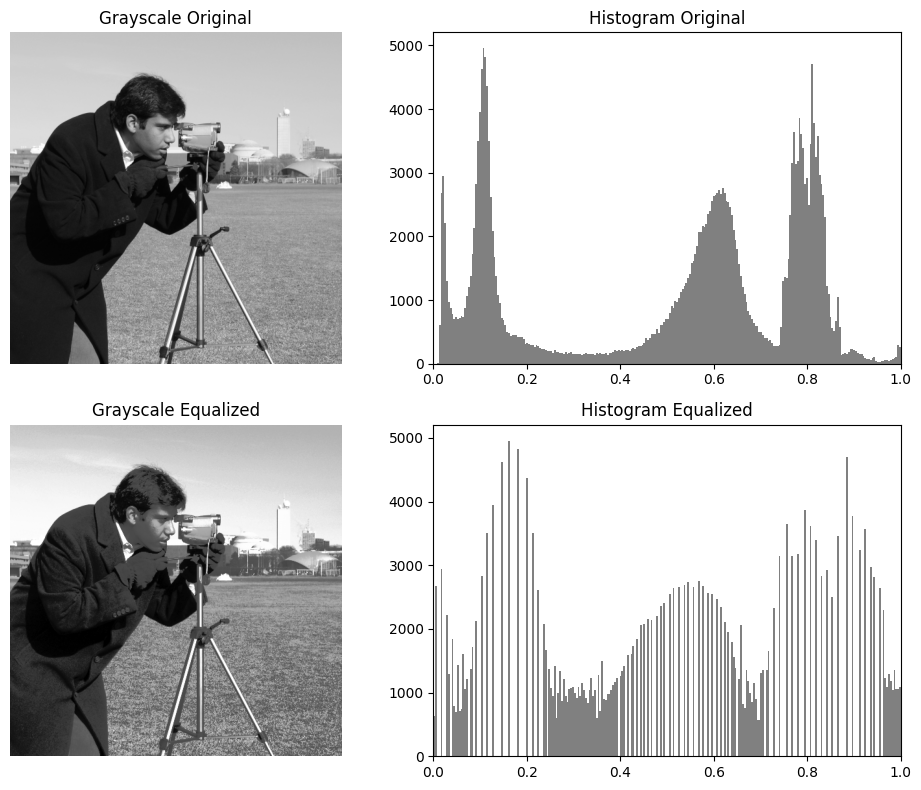

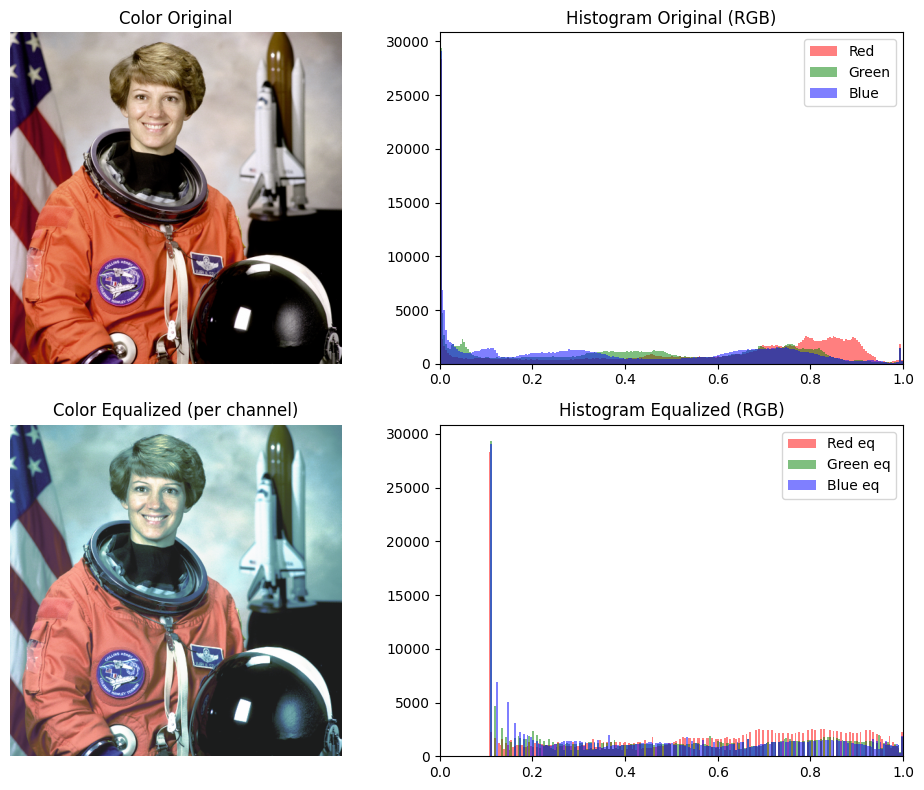

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# -----------------------------------------------------
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# -----------------------------------------------------

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# -------------------------------------------------------

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

# 2. Ambil kanal RGB
r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

# 3. Histogram per kanal
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

# 4. Ekualisasi histogram per kanal (independen)
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali ke RGB
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Histogram hasil ekualisasi
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

# 5. Plot hasil
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli RGB
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Setelah Ekualisasi
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi RGB
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


**Praktikum 3. Konvolusi (Filter Rata-rata)**

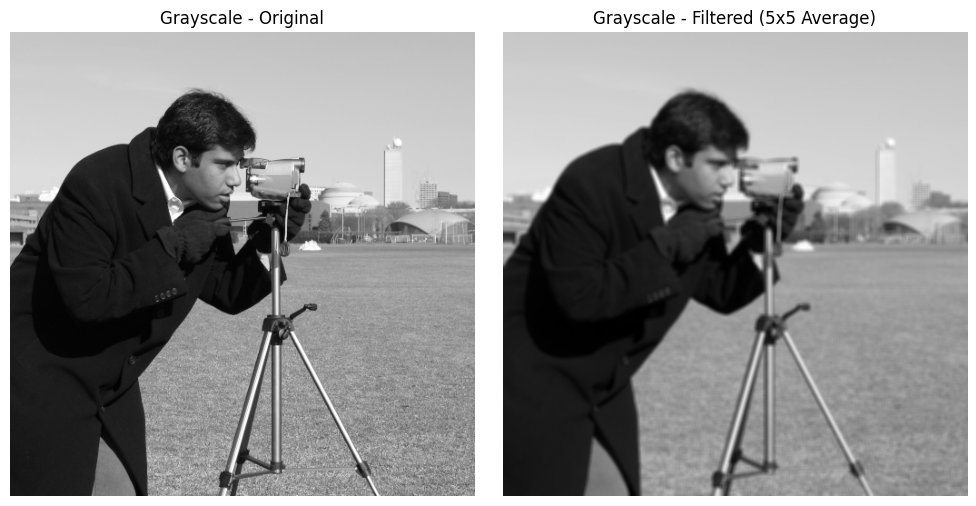

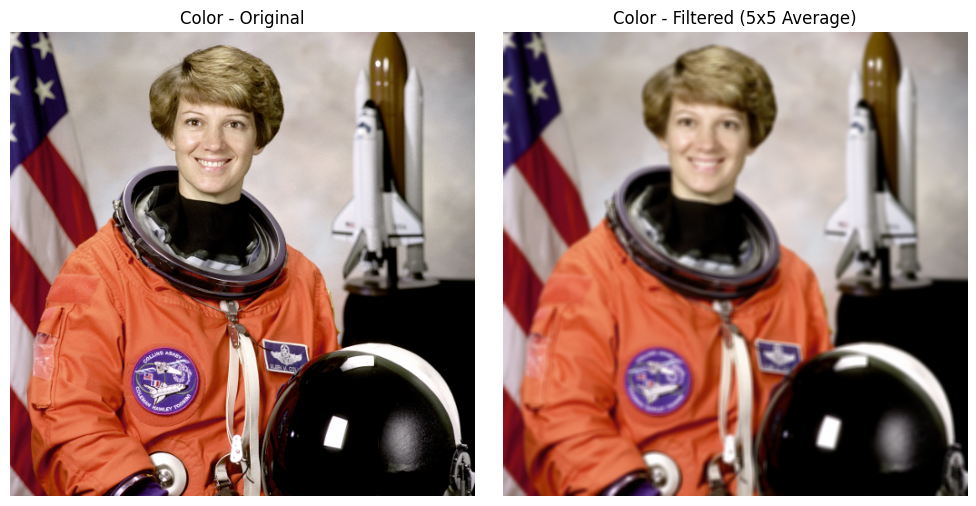

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# --------------------------------------------------
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# --------------------------------------------------

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B secara terpisah, lalu gabungkan
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

**Praktikum 4. Filter Median (penghilangan noise/derau)**

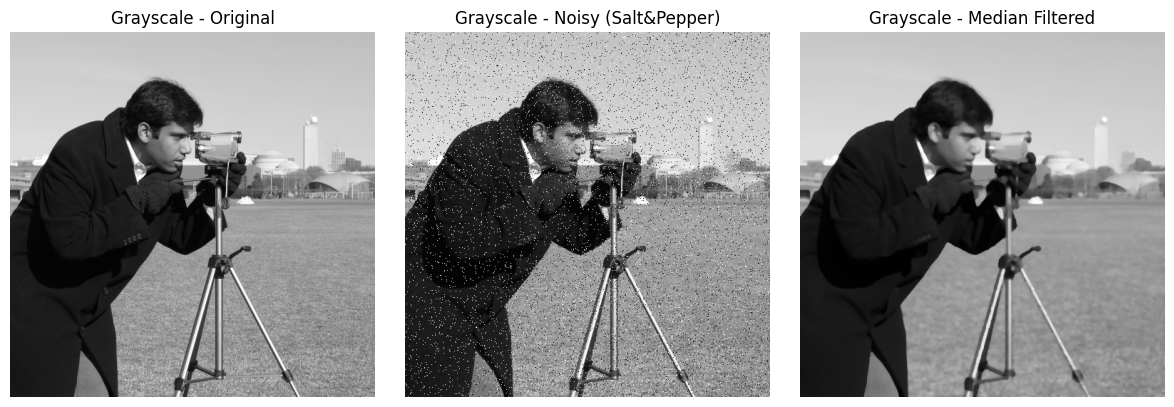

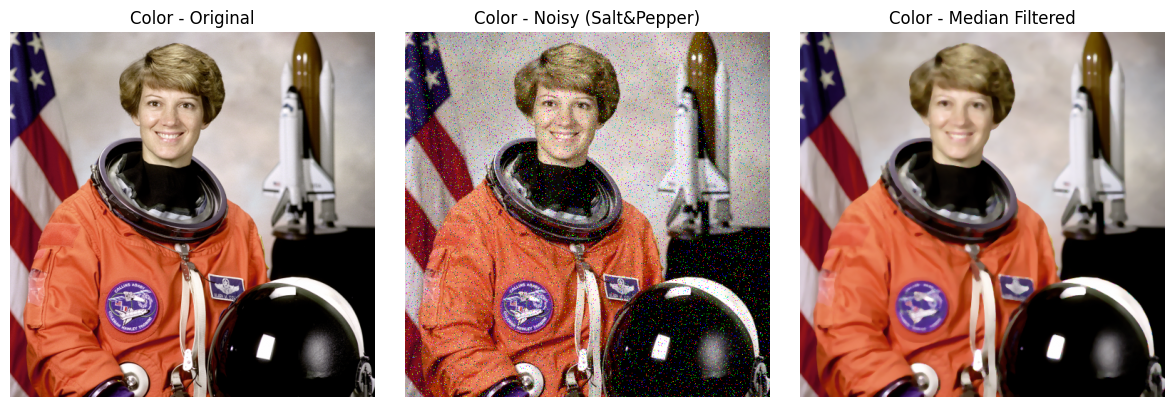

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# -----------------------------------------
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
# -----------------------------------------

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()    # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)
# amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
#    Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# -----------------------------------------

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()    # RGB, uint8
color_float = img_as_float(color_uint8)  # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
#    Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
#    atau kita bisa memanggil per kanal. Di sini langsung:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


**Penugasan no. 3**

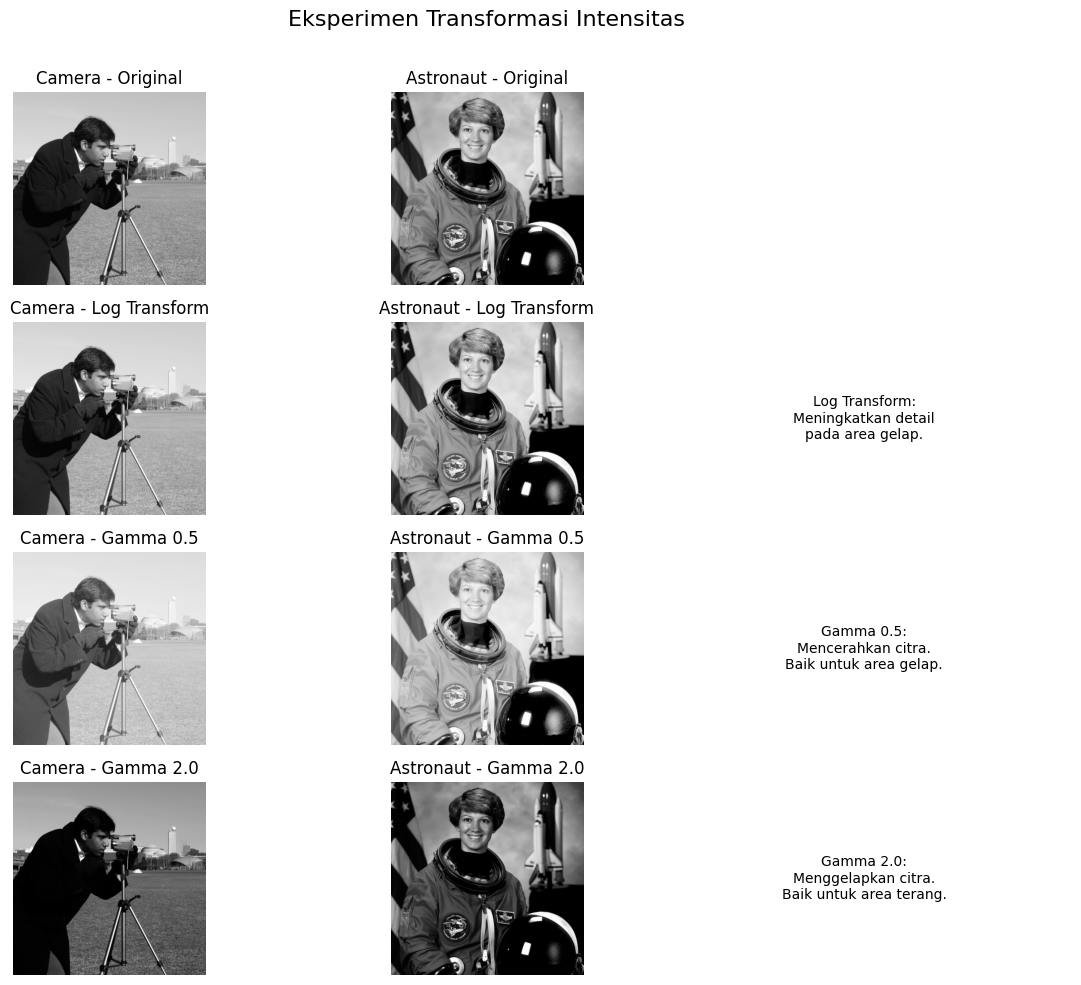

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# -----------------------------------------------------------
# 1. Memuat dua citra grayscale: camera dan astronaut
# -----------------------------------------------------------
gray_camera = img_as_float(data.camera())  # asli sudah grayscale
gray_astronaut = img_as_float(color.rgb2gray(data.astronaut()))  # ubah ke grayscale

# -----------------------------------------------------------
# 2. Transformasi Logaritmik
# -----------------------------------------------------------
camera_log = exposure.adjust_log(gray_camera, gain=1)
astronaut_log = exposure.adjust_log(gray_astronaut, gain=1)

# -----------------------------------------------------------
# 3. Transformasi Gamma
# Gamma < 1 (mencerahkan), Gamma > 1 (menggelapkan)
# -----------------------------------------------------------
gamma_low = 0.5
gamma_high = 2.0

camera_gamma_low = exposure.adjust_gamma(gray_camera, gamma=gamma_low, gain=1)
camera_gamma_high = exposure.adjust_gamma(gray_camera, gamma=gamma_high, gain=1)

astronaut_gamma_low = exposure.adjust_gamma(gray_astronaut, gamma=gamma_low, gain=1)
astronaut_gamma_high = exposure.adjust_gamma(gray_astronaut, gamma=gamma_high, gain=1)

# -----------------------------------------------------------
# 4. Visualisasi
# -----------------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
fig.suptitle("Eksperimen Transformasi Intensitas", fontsize=16)

# Baris 1: Asli
axes[0, 0].imshow(gray_camera, cmap='gray')
axes[0, 0].set_title("Camera - Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(gray_astronaut, cmap='gray')
axes[0, 1].set_title("Astronaut - Original")
axes[0, 1].axis('off')

axes[0, 2].axis('off')  # Kosong

# Baris 2: Log Transform
axes[1, 0].imshow(camera_log, cmap='gray')
axes[1, 0].set_title("Camera - Log Transform")
axes[1, 0].axis('off')

axes[1, 1].imshow(astronaut_log, cmap='gray')
axes[1, 1].set_title("Astronaut - Log Transform")
axes[1, 1].axis('off')

axes[1, 2].text(0.5, 0.5,
                "Log Transform:\nMeningkatkan detail\npada area gelap.",
                ha='center', va='center', fontsize=10)
axes[1, 2].axis('off')

# Baris 3: Gamma < 1 (terang)
axes[2, 0].imshow(camera_gamma_low, cmap='gray')
axes[2, 0].set_title(f"Camera - Gamma {gamma_low}")
axes[2, 0].axis('off')

axes[2, 1].imshow(astronaut_gamma_low, cmap='gray')
axes[2, 1].set_title(f"Astronaut - Gamma {gamma_low}")
axes[2, 1].axis('off')

axes[2, 2].text(0.5, 0.5,
                f"Gamma {gamma_low}:\nMencerahkan citra.\nBaik untuk area gelap.",
                ha='center', va='center', fontsize=10)
axes[2, 2].axis('off')

# Baris 4: Gamma > 1 (gelap)
axes[3, 0].imshow(camera_gamma_high, cmap='gray')
axes[3, 0].set_title(f"Camera - Gamma {gamma_high}")
axes[3, 0].axis('off')

axes[3, 1].imshow(astronaut_gamma_high, cmap='gray')
axes[3, 1].set_title(f"Astronaut - Gamma {gamma_high}")
axes[3, 1].axis('off')

axes[3, 2].text(0.5, 0.5,
                f"Gamma {gamma_high}:\nMenggelapkan citra.\nBaik untuk area terang.",
                ha='center', va='center', fontsize=10)
axes[3, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Penugasan no.4**

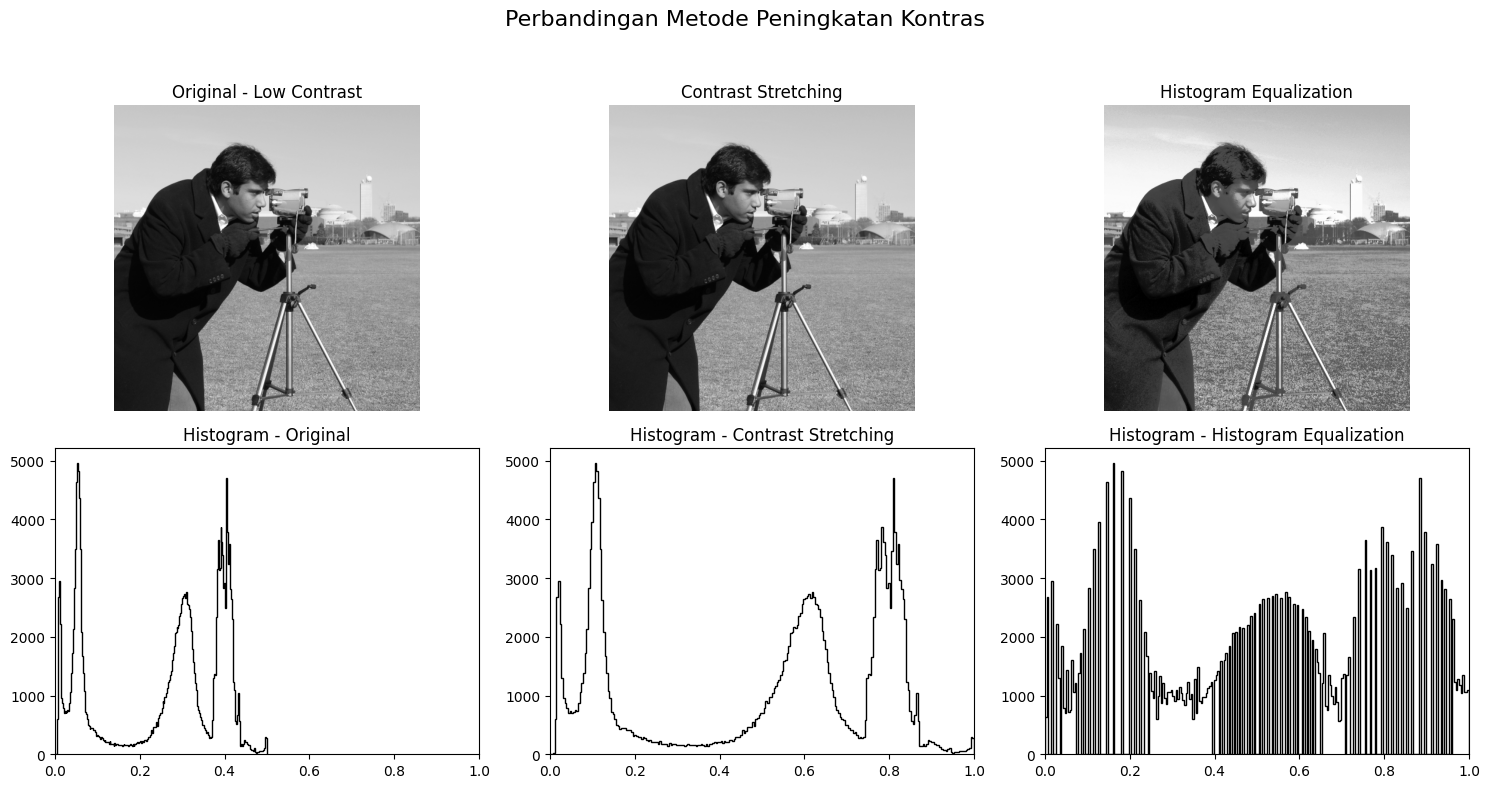


🔎 INTERPRETASI HASIL:

1. ORIGINAL IMAGE:
   - Citra tampak gelap karena semua nilai intensitasnya kecil.
   - Histogramnya sempit dan terkumpul di kiri (area gelap).

2. CONTRAST STRETCHING:
   - Mengubah rentang nilai piksel dari aslinya ke rentang penuh (0 sampai 1).
   - Citra menjadi lebih kontras, tapi bentuk histogram tetap serupa dengan aslinya, hanya direntangkan.
   - Cocok kalau distribusi nilai aslinya hanya perlu diperluas.

3. HISTOGRAM EQUALIZATION:
   - Mengubah distribusi piksel agar lebih merata ke seluruh rentang intensitas.
   - Citra jadi tampak 'lebih detail', terutama di bagian gelap/terang.
   - Histogram jadi menyebar lebih merata (flattened histogram).
   - Bisa memberikan peningkatan kontras yang lebih dramatis, tapi kadang over-enhanced (terlalu ekstrem).

✅ KESIMPULAN:
👉 Jika ingin kontras LEBIH NATURAL dan TERKENDALI, gunakan: CONTRAST STRETCHING.
👉 Jika ingin kontras LEBIH TAJAM atau EKSTRIM, gunakan: HISTOGRAM EQUALIZATION.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float
from skimage.util import img_as_ubyte

# -----------------------------------------------------------
# 1. Ambil gambar grayscale yang kontrasnya rendah
# Di sini kita ubah brightness gambar camera jadi rendah
# -----------------------------------------------------------
gray_camera = img_as_float(data.camera())
low_contrast_image = gray_camera * 0.5  # Buat jadi lebih gelap

# -----------------------------------------------------------
# 2. Terapkan Contrast Stretching
# -----------------------------------------------------------
contrast_stretched = exposure.rescale_intensity(low_contrast_image, in_range='image', out_range=(0, 1))

# -----------------------------------------------------------
# 3. Terapkan Histogram Equalization
# -----------------------------------------------------------
equalized = exposure.equalize_hist(low_contrast_image)

# -----------------------------------------------------------
# 4. Fungsi bantu untuk tampilkan histogram
# -----------------------------------------------------------
def plot_hist(ax, image, title):
    ax.hist(image.ravel(), bins=256, histtype='step', color='black')
    ax.set_title(title)
    ax.set_xlim(0, 1)

# -----------------------------------------------------------
# 5. Visualisasi Gambar & Histogram
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Perbandingan Metode Peningkatan Kontras", fontsize=16)

# Baris 1: Gambar
axes[0, 0].imshow(low_contrast_image, cmap='gray')
axes[0, 0].set_title("Original - Low Contrast")
axes[0, 0].axis('off')

axes[0, 1].imshow(contrast_stretched, cmap='gray')
axes[0, 1].set_title("Contrast Stretching")
axes[0, 1].axis('off')

axes[0, 2].imshow(equalized, cmap='gray')
axes[0, 2].set_title("Histogram Equalization")
axes[0, 2].axis('off')

# Baris 2: Histogram
plot_hist(axes[1, 0], low_contrast_image, "Histogram - Original")
plot_hist(axes[1, 1], contrast_stretched, "Histogram - Contrast Stretching")
plot_hist(axes[1, 2], equalized, "Histogram - Histogram Equalization")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n🔎 INTERPRETASI HASIL:\n")

print("1. ORIGINAL IMAGE:")
print("   - Citra tampak gelap karena semua nilai intensitasnya kecil.")
print("   - Histogramnya sempit dan terkumpul di kiri (area gelap).")

print("\n2. CONTRAST STRETCHING:")
print("   - Mengubah rentang nilai piksel dari aslinya ke rentang penuh (0 sampai 1).")
print("   - Citra menjadi lebih kontras, tapi bentuk histogram tetap serupa dengan aslinya, hanya direntangkan.")
print("   - Cocok kalau distribusi nilai aslinya hanya perlu diperluas.")

print("\n3. HISTOGRAM EQUALIZATION:")
print("   - Mengubah distribusi piksel agar lebih merata ke seluruh rentang intensitas.")
print("   - Citra jadi tampak 'lebih detail', terutama di bagian gelap/terang.")
print("   - Histogram jadi menyebar lebih merata (flattened histogram).")
print("   - Bisa memberikan peningkatan kontras yang lebih dramatis, tapi kadang over-enhanced (terlalu ekstrem).")

print("\n✅ KESIMPULAN:")
print("👉 Jika ingin kontras LEBIH NATURAL dan TERKENDALI, gunakan: CONTRAST STRETCHING.")
print("👉 Jika ingin kontras LEBIH TAJAM atau EKSTRIM, gunakan: HISTOGRAM EQUALIZATION.")

**Penugasan no.5**

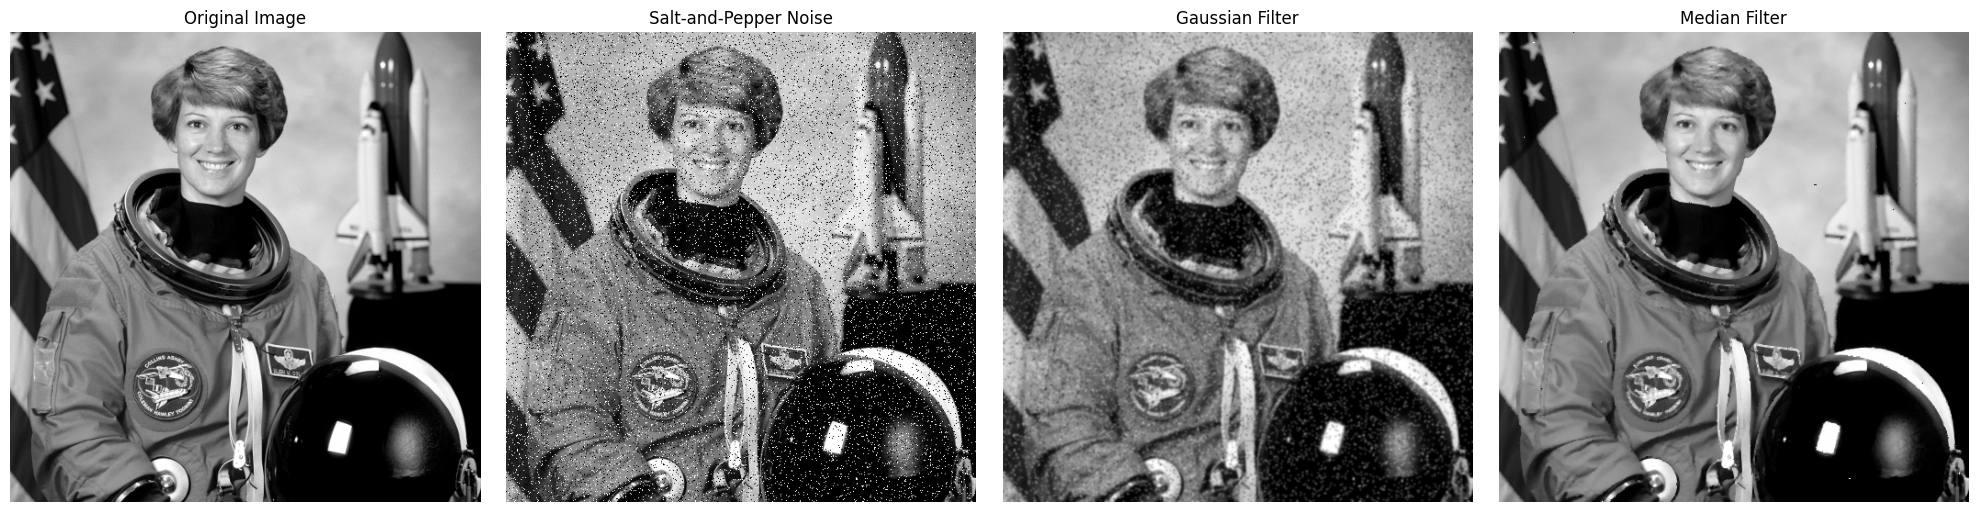


🔎 INTERPRETASI:

1. ORIGINAL IMAGE:
   - Gambar asli tanpa noise, dengan detail tepi yang tajam.

2. SALT-AND-PEPPER NOISE:
   - Terlihat titik-titik hitam & putih menyebar di seluruh gambar (impulse noise).
   - Ini tipe noise yang 'sulit' diatasi dengan filter rata-rata.

3. GAUSSIAN FILTER:
   - Mengaburkan (blur) gambar untuk mengurangi noise.
   - Beberapa noise hilang, tetapi banyak yang masih tersisa.
   - Detail tepi juga menjadi kabur karena filter ini 'meratakan' semua piksel.

4. MEDIAN FILTER:
   - Noise salt-and-pepper hampir hilang total.
   - Detail tepi tetap terjaga lebih baik dibanding Gaussian.
   - Filter median efektif untuk menghilangkan impulse noise karena mengganti nilai piksel dengan nilai tengah dari tetangganya, bukan rata-rata.

✅ KESIMPULAN:
👉 Untuk mengatasi SALT-AND-PEPPER NOISE, MEDIAN FILTER lebih unggul karena bisa menghilangkan noise tanpa mengorbankan detail gambar.
👉 GAUSSIAN FILTER lebih cocok untuk noise Gaussian atau untuk general smoothing, te

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, util, filters, restoration
from scipy.ndimage import median_filter, convolve

# 1. Load citra grayscale
image = color.rgb2gray(data.astronaut())

# 2. Tambahkan noise salt-and-pepper
noisy_image = util.random_noise(image, mode='s&p', amount=0.1)

# 3. Filter rata-rata menggunakan Gaussian
gaussian_filtered = filters.gaussian(noisy_image, sigma=1)

# 4. Filter median
median_filtered = median_filter(noisy_image, size=3)

# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(noisy_image, cmap='gray')
ax[1].set_title("Salt-and-Pepper Noise")
ax[1].axis('off')

ax[2].imshow(gaussian_filtered, cmap='gray')
ax[2].set_title("Gaussian Filter")
ax[2].axis('off')

ax[3].imshow(median_filtered, cmap='gray')
ax[3].set_title("Median Filter")
ax[3].axis('off')

plt.tight_layout()
plt.show()

# 6. INTERPRETASI HASIL
print("\n🔎 INTERPRETASI:\n")

print("1. ORIGINAL IMAGE:")
print("   - Gambar asli tanpa noise, dengan detail tepi yang tajam.")

print("\n2. SALT-AND-PEPPER NOISE:")
print("   - Terlihat titik-titik hitam & putih menyebar di seluruh gambar (impulse noise).")
print("   - Ini tipe noise yang 'sulit' diatasi dengan filter rata-rata.")

print("\n3. GAUSSIAN FILTER:")
print("   - Mengaburkan (blur) gambar untuk mengurangi noise.")
print("   - Beberapa noise hilang, tetapi banyak yang masih tersisa.")
print("   - Detail tepi juga menjadi kabur karena filter ini 'meratakan' semua piksel.")

print("\n4. MEDIAN FILTER:")
print("   - Noise salt-and-pepper hampir hilang total.")
print("   - Detail tepi tetap terjaga lebih baik dibanding Gaussian.")
print("   - Filter median efektif untuk menghilangkan impulse noise karena mengganti nilai piksel dengan nilai tengah dari tetangganya, bukan rata-rata.")

print("\n✅ KESIMPULAN:")
print("👉 Untuk mengatasi SALT-AND-PEPPER NOISE, MEDIAN FILTER lebih unggul karena bisa menghilangkan noise tanpa mengorbankan detail gambar.")
print("👉 GAUSSIAN FILTER lebih cocok untuk noise Gaussian atau untuk general smoothing, tetapi kurang efektif untuk impuls noise.")
